### План

1. **Ансамбли алгоритмов (стекинг)**

    - Базовые модели (base learners)

    - Метамодель (meta-model)

2. **Комитеты голосования (усреднение)**

    - Бутстрап

    - Бэггинг (bootstrap aggregating)

    - Случайные подпространства

    - Случайный лес

4. **Построение разделяющих границ**

5. **Бустинг**
  
    - AdaBoost

    - Градиентный спуск

    - Градиентный бустинг (XGBoost)

6. **Стекинг**

    - Стекинг

    - Блендинг

In [1]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from sklearn.model_selection import train_test_split

import warnings

warnings.filterwarnings("ignore")

Загрузим данные для обработки. Разделим на тренировочную и обучающую выборки.

In [2]:
# Разделяем на тренировочные и тестовые данные
data = pd.read_csv('train.csv')
data_train, data_test, y_train, y_test = train_test_split(data.drop(columns='SalePrice'), data['SalePrice'], test_size=0.30, random_state=42)

# Находим категориальные признаки
categorials = list(data.dtypes[data.dtypes == "str"].index)
categorials_nunique = data_train[categorials].nunique()

# Закодируем пропущенные значений строкой, факт пропущенного значения тоже может нести в себе информацию
data[categorials] = data[categorials].fillna('nan')

# Отфильтруем непрерывные признаки
integer = [f for f in data if f not in (categorials + ['ID', 'SalePrice'])]

In [3]:
# Создаем дамми-переменные для категорий
dummy_train = pd.get_dummies(data_train[categorials], columns=categorials)
dummy_test = pd.get_dummies(data_test[categorials], columns=categorials)

dummy_cols = list(set(dummy_train) & set(dummy_test))
dummy_train = dummy_train[dummy_cols]
dummy_test = dummy_test[dummy_cols]

# Заменяем пропуски на специальное значение -999, чтобы деревья могли их отличить
X_train = pd.concat([data_train[integer].fillna(-999), dummy_train], axis=1)
X_test = pd.concat([data_test[integer].fillna(-999), dummy_test], axis=1)

In [4]:
X_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,ExterCond_TA,Exterior1st_MetalSd,HeatingQC_Ex,Condition1_RRAe,ExterQual_Ex,ExterCond_Gd,Utilities_AllPub,KitchenQual_Gd,GarageType_Basment,GarageQual_TA
135,136,20,80.000,10400,7,6,1970,1970,288.000,0,...,True,False,False,False,False,False,True,False,False,True
1452,1453,180,35.000,3675,5,5,2005,2005,80.000,547,...,True,False,False,False,False,False,True,False,True,True
762,763,60,72.000,8640,7,5,2009,2009,0.000,24,...,True,False,True,False,False,False,True,True,False,True
932,933,20,84.000,11670,9,5,2006,2006,302.000,0,...,True,False,True,False,True,False,True,False,False,True
435,436,60,43.000,10667,7,6,1996,1996,0.000,385,...,True,False,True,False,False,False,True,True,False,True


## 1. Ансамбли алгоритмов (стекинг)

Ансамблирование - одна из самых мощных техник машинного обучения. Это объединение нескольких моделей для получения более сильного предсказания.

**Базовые модели** (base learners) обучаются на исходных данных.

**Метамодель** (meta-model) обучается на предсказаниях базовых моделей.

Стекинг представляет собой объединение прогнозов нескольких разных моделей (базовых алгоритмов) с помощью финальной "метамодели".

Формула стекинга:

$$\hat y = f_{meta}(f_1(x), f_2(x), ..., f_n(x))$$

In [5]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import RidgeCV

In [6]:
# Создаем стекинг и обучаем его на наших данных 

base_models = [
    ('SVR', SVR()),
    ('LinearRegression', LinearRegression()),
    ('KNeighborsRegressor', KNeighborsRegressor()),
    ('DecisionTree', DecisionTreeRegressor())
]
meta_model = RidgeCV()

stack = StackingRegressor(estimators=base_models, final_estimator=meta_model)
stack.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('SVR', ...), ('LinearRegression', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RidgeCV()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001


Посмотрим, какая модель сработает лучше всех.

In [7]:
# Посчитаем метрики для всех моделей 

print(f'Score on train data {stack.score(X_train, y_train)}')
print(f'Score on test data {stack.score(X_test, y_test)}')

for i in stack.named_estimators:
    print(f'Score on train data with model {i} {stack.named_estimators_[i].score(X_train, y_train)}')
    print(f'Score on test data with model {i} {stack.named_estimators_[i].score(X_test, y_test)}')

Score on train data 0.9469942626094288
Score on test data 0.8626220134737214
Score on train data with model SVR -0.043873952784005965
Score on test data with model SVR -0.03198238589501523
Score on train data with model LinearRegression 0.9219862289264096
Score on test data with model LinearRegression 0.8534304622785123
Score on train data with model KNeighborsRegressor 0.7419951520813983
Score on test data with model KNeighborsRegressor 0.6775304068635524
Score on train data with model DecisionTree 1.0
Score on test data with model DecisionTree 0.7671303418025848


- Лучше всех справилась Линейная регрессия (LinearRegression).

- Алгоритм Decision Tree, как и предполагалось, переобучился.

## 2. Комитеты голосования (усреднение)

К таким алгоритмам относятся бутстрап, бэггинг, случайный лес. Они используют усреднение результатов, тем самым давая более устойчивую и надежную оценку.

### **Бутстрап** 
— это метод, который позволяет оценить распределение выборочной статистики (медиана, эксцесс, среднее значение) путем многократной генерации выборок методом Монте-Карло на основе исходной выборки. 

Бутстреп-выборки («псевдовыборки») производятся равномерно и с возвращением, поэтому некоторые исходные примеры будут отсутствовать, а другие - дублироваться: в среднем одна такая выборка содержит около 2/3 уникальных исходных наблюдений. Каждая такая выборка стремится быть репрезентативной генеральной совокупности.

В английском есть выражение *"pull yourself by your bootstraps"* (*"поднять себя вверх за ремешки на ботинках"*), которое означает выполнение сложного/невыполнимого задания, в котором нужно проявить собственные усилия без посторонней помощи.

Так и в случае с алгоритмом бутстрапа, выборка формируется без посторонней помощи (информации).

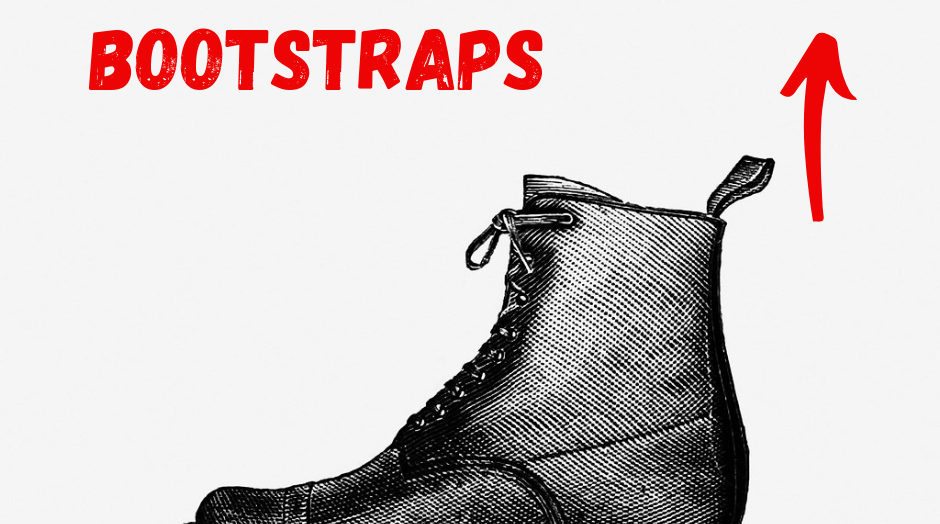

Бутстрап применяется в тех случаях, когда теоретическое распределение данных неизвестно, либо объем выборки мал для прямой статистической оценки. Также, бутстрап можно использовать, когда необходима оценка сложных статистик, для которых сложно получить аналитические формулы.

Формула бутстрапа:


$$D^* = {x_{i}^{(1)}, x_{i}^{(2)}, ..., x_{i}^{(n)}}, x_{i} \sim D$$


Реализуем бутстрап.

In [8]:
import numpy as np

# Зададим исходную вьборку данных
data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
n_samples = len(data)
n_bootstraps = 10000
bootstrap_means = []

for _ in range(n_bootstraps):
    # Создадим выборку бутстрапа путем замены 10000 раз
    bootstrap_sample = np.random.choice(data, size=n_samples, replace=True)
    bootstrap_means.append(np.mean(bootstrap_sample))

# Посчитаем 95-процентый доверительный интервал
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

print(f"Исходное среднее значение: {np.mean(data)}")
print(f"95% доверительный интервал бутстрапа: [{lower_bound}, {upper_bound}]")

Исходное среднее значение: 5.5
95% доверительный интервал бутстрапа: [3.7, 7.3]


### **Бэггинг** 
— обучение множества моделей на разных бутстрап-выборках и усреднение их предсказаний.

Бэггинг использует базовые алгоритмы и обучает на случайном подмножестве выборки.

Если вместо отдельных обучающих выборок выполнить бутстреп и на основе сгенерированных псевдо-выборок построить $B$ деревьев регрессии, то средний коллективный прогноз

$$\hat f_{bag} = \dfrac{f^{1}(x) + f^{2}(x) + ... + f^{B}(x)}{B}$$

будет обладать более низкой дисперсией. Эта процедура и называется бэггингом (**b**ootstrap **agg**regat**ing**).


Формула бэггинга:

$$\hat f_{bag}(x) = \dfrac{1}{B} \sum^{B}_{b=1} f_{b}(x)$$

Реализуем бэггинг.

In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [10]:
# Создадим словарь моделей для бэггинга
models = {
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=10),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR()
}

# Создадим словарь для хранения результатов
results = []

# Обучим и оценим каждую модель с бэггингом
for name, base_model in models.items():
    # Бэггинг модели
    bagging = BaggingRegressor(
        estimator=base_model,
        n_estimators=100,
        bootstrap=True,
        random_state=42
    )
    bagging.fit(X_train, y_train)
    
    # Подсчитаем предсказания и метрики
    y_pred = bagging.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    results.append({
        "Модель": name,
        "R²": round(r2, 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4)
    })

# Выведем результаты в виде таблицы
results_df = pd.DataFrame(results)
print("Результаты бэггинга для трёх моделей:")
print(results_df.to_markdown(index=False))

Результаты бэггинга для трёх моделей:
| Модель       |      R² |     MAE |         MSE |
|:-------------|--------:|--------:|------------:|
| DecisionTree |  0.891  | 17063.4 | 7.60655e+08 |
| RandomForest |  0.8842 | 17040.1 | 8.08311e+08 |
| KNN          |  0.6701 | 30085.4 | 2.30183e+09 |
| SVR          | -0.0329 | 57021.2 | 7.2079e+09  |


### **Случайные подпространства** (random subspaces) набора данных используются для того, чтобы производить обучение моделей на случайных подмножествах признаков. 

В этом методе 

- берутся все объекты исходной выборки;

- сэмплируются признаки без возвращения.

Если обучить модель на получившейся выборке, она будет использовать только часть от всех располагаемых признаков.

In [11]:
from sklearn.base import clone
import random

# Создадим класс для реализации случайных подпространств
class RandomSubspaceEnsemble:
    def __init__(self, estimator, n_estimators=10, subsample_ratio=0.7, random_state=None):
        self.estimator = estimator
        self.n_estimators = n_estimators
        self.subsample_ratio = subsample_ratio
        self.random_state = random_state
        self.models = []
        
    def fit(self, X, y):
        random.seed(self.random_state)
        num_features = X.shape[1]
        feature_indices = list(range(num_features))
        
        for _ in range(self.n_estimators):
            # Выбираем случайное подмножество признаков
            subset_size = int(self.subsample_ratio * num_features)
            selected_features = random.sample(feature_indices, subset_size)
            
            # Клонируем базовую модель и обучаем на выбранных признаках
            model = clone(self.estimator)
            model.fit(X.iloc[:, selected_features], y)
            self.models.append((model, selected_features))
    
    def predict(self, X):
        predictions = []
        for model, features in self.models:
            pred = model.predict(X.iloc[:, features])
            predictions.append(pred)
        
        # Усредняем прогнозы
        ensemble_prediction = np.mean(predictions, axis=0)
        return ensemble_prediction


# Обучим ансамбль
base_model = DecisionTreeRegressor(random_state=42)

ensemble = RandomSubspaceEnsemble(base_model, n_estimators=20, subsample_ratio=0.7, random_state=42)

ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMS Error: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

RMS Error: 28867.61
R² Score: 0.8806


### **Случайный лес** 
включает в себя  бэггинг + случайные подпространства.

Данный алгоритм использует ансамбль решающих деревьев, каждое из которых само по себе дает очень невысокое качество классификации, но за счет их большого количества получается необходимый результат.

**Преимущества случайного леса:**

- высокая точнсть прогнозов;

- не требует тщательной настройки параметров;

- способность эффективно обрабатывать данные с большим числом признаков и классов;

- редко переобучается, добавление деревьев почти всегда улучшает композицию;

- не чувствителен к выбросам в данных, масштабированию, пропускам.


**Недостатки случайного леса:**

- сложнее интерпретировать результаты;

- не умеет экстраполировать;

- склонен к переобучению, особенно на сильно зашумленных данных;

- требуется больше памяти для хранения итоговых моделей $O(N*K)$.

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf.predict(X_test)
preds = rf.predict(X_test)

mse = mean_squared_error(y_test, preds)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 734434358.2614


## 3. Построение разделяющих границ

Разделяющие границы в задаче **классификации** строятся с целью показать, насколько хорошо модель научилась разделять классы. Если разделяющие границы четкие, это означает, что модель хорошо научилась классифицировать. Если же присутствуют дополнительные линии между областями, это говорит о том, что классификация неточная.

В задаче **регрессии** рассматриваются по аналогии **поверхности решений** (decision surfaces), показывающие, как модель отображает пространство признаков в пространство предсказанных значений.

Давайте обучим линейную регрессию и визуализируем разделяющие поверхности.

Сначала отберем наиболее важные признаки, по которым будем строить поверхности. 

Будем оценивать среднее уменьшение дисперсии (Mean Decrease Impurity, MDI) - критерий, который оценивает вклад каждого признака в снижение дисперсии целевой переменной.

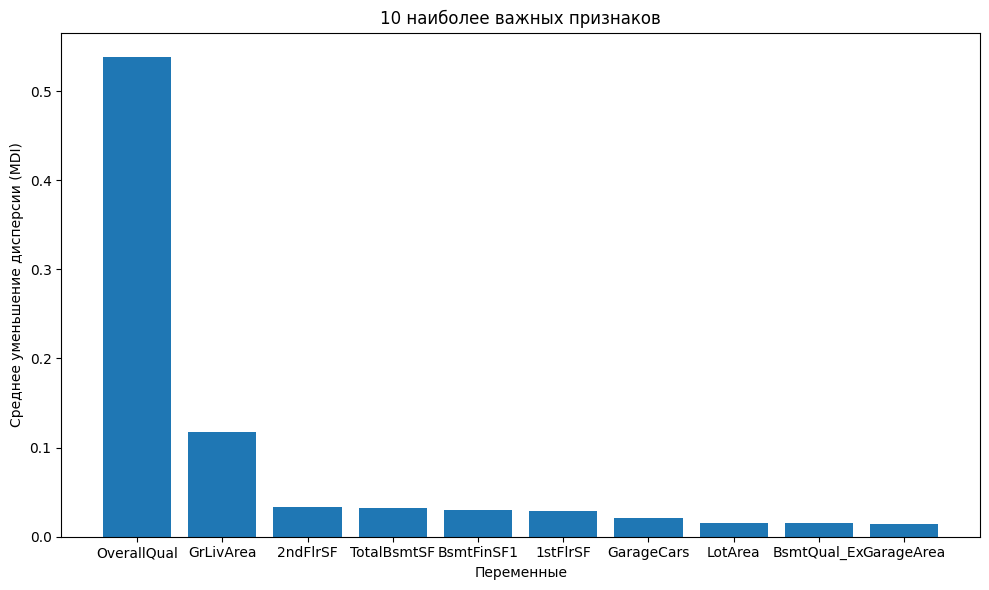

In [13]:
import matplotlib.pyplot as plt

# Получаем важности признаков по случайному лесу
# feature_importances - среднее уменьшение дисперсии
importances = pd.Series(rf.feature_importances_)
importances.index = pd.Series(X_train.columns)

# Выведем на график
plt.figure(figsize=(10, 6))
plt.title('10 наиболее важных признаков')
plt.xlabel('Переменные')
plt.ylabel('Среднее уменьшение дисперсии (MDI)')
plt.bar(importances.sort_values(ascending=False).head(10).index, 
        importances.sort_values(ascending=False).head(10))
plt.tight_layout()
plt.show()

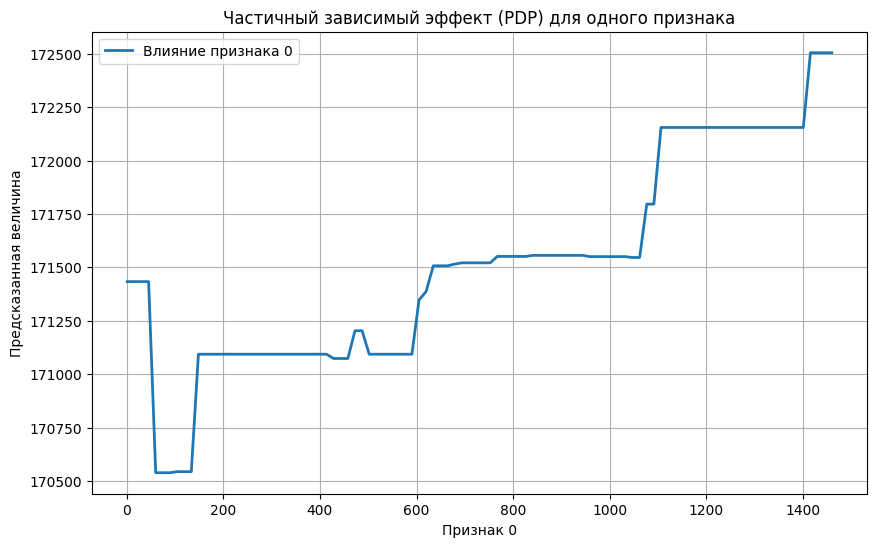

In [14]:
feature_idx = 4

# Преобразуем DataFrame в NumPy-массив
X_train_np = X_train.values

# Теперь работаем с массивом
feature_idx = 0  # Индекс признака, который хотим исследовать
feature_range = np.linspace(X_train_np[:, feature_idx].min(), X_train_np[:, feature_idx].max(), 100)

# Продолжаем работу с массивом
fixed_features = X_train_np.mean(axis=0).reshape(1, -1)

predictions = []

for value in feature_range:
    # Меняем только исследуемый признак, остальные фиксированные
    input_data = fixed_features.copy()
    input_data[:, feature_idx] = value
    prediction = rf.predict(input_data)[0]
    predictions.append(prediction)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(feature_range, predictions, label=f"Влияние признака {feature_idx}", lw=2)
plt.xlabel(f"Признак {feature_idx}")
plt.ylabel("Предсказанная величина")
plt.title("Частичный зависимый эффект (PDP) для одного признака")
plt.legend()
plt.grid(True)
plt.show()

## 4. Бустинг

Бустинг - это процедура последовательного построения композиции алгоритмов, когда каждый следующий алгоритм стремится компенсировать недостатки композиции всех предыдущих алгоритмов. Тем самым, бустинг - это жадный алгоритм. Он преобразует слабые модели в сильные.

Пусть мы хотим создать более сильный классификатор с помощью бустинга.

Если у нас есть набор данных, в котором $n$ - количество точек и

$$x_{i} \in \R^{d}, y_{i} \in \{-1,1\},$$

где -1 будет отрицательным классом, а 1 - положительным. Тогда вес каждой точки будет инициализирован, как показано ниже (на основе результатов работы предыдущего классификатора):

$$w(x_{i}, y_{i}) = \dfrac{1}{n}, i = 1, ..., n.$$

Выберем слабый классификатор с наименьшей взвешенной ошибкой классификации, применив классификатор к набору данных.

### **Adaboost** (Adaptive Boosting) обучается по следующей формуле:

$$\alpha_{m} = \dfrac{1}{2} ln (\dfrac{1 - \epsilon_{m}}{ \epsilon_{m}})$$

Adaboost тем самым помогает выбрать обучающий набор для каждого классификатора, который обучается на основе результатов работы предыдущего классификатора.

Реализуем Adaboost.

In [15]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
pred = ada.predict(X_test)

In [16]:
from  sklearn.metrics import r2_score

r2_score(pred, y_test)

0.7512407016527762

### Градиентный спуск

**Градиентный спуск** — это алгоритм оптимизации, используемый для минимизации ошибок в модели машинного обучения. 

Он итеративно корректирует параметры модели в направлении **антиградиента** - отрицательного градиента функции потерь (которая представляет ошибку), чтобы уменьшить ошибку и найти оптимальные параметры, которые дают наилучшие результаты прогнозирования. 

Алгоритм продолжает этот процесс до тех пор, пока он не достигнет минимума или не будет выполнен заранее определенный критерий остановки.

### Градиентный бустинг

Как и в случае с Adaboost, градиентный бустинг добавляет базовые модели в ансамбль последовательно, однако вместо обучения моделей с учётом весов на основе ошибок предшественников, в данном случае модели обучаются на остаточных ошибках (residual errors), допущенных предыдущими моделями.

Алгоритм строится следующим образом:

- 1. Присваиваем первоначальному прогнозу среднее значение y_train для всех образцов

- 2. Рассчитываем остатки модели на основе **антиградиента функции потерь**

- 3. Обучаем регрессионное дерево на X_train и остатках

- 4. Делаем прогноз на X_train

- 5. Добавляем полученный прогноз к первоначальному

Формула обновления:

$$F_{m}(x) = F_{m-1}(x) + v * h_{m}(x),$$

где $h_{m}$ - новое дерево, $v$ - learning rate.

6. Повторяем шаги 2-5 для каждого дерева

7. После обучения всех моделей снова создаем первоначальный прогноз из шага 1

8. Делаем прогнозы для X_test на обученных деревьях и добавляем к первоначальному

9. Полученная сумма и будет конечным прогнозом

In [17]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
pred = xgb_model.predict(X_test)

In [18]:
r2_score(pred, y_test)

0.8794379234313965

На основе $R^{2}$ можем сказать, что XGBoost справился лучше, чем Adaboost.

### Блендинг


Блендинг — упрощённая версия стекинга, где:

- Деление данных на две части: одна часть используется для тренировки базовых моделей, вторая — для создания метанабора.

- Нет кросс-валидации: все базовые модели обучаются на первой части данных, а предсказания создаются на второй части.

Алгоритм блендинга:

1. **Разделение данных**: исходный датасет делится на две части:

    - Первая часть (train) — для тренировки базовых моделей.

    - Вторая часть (validation) — для создания метанабора.

2. **Тренировка базовых моделей**: модели обучаются на первой части данных.

3. **Создание метанабора**: предсказания базовых моделей получаются на второй части (validation set).

4. **Обучение метамодели**: метамодель обучается на метанаборе, состоящем из предсказаний базовых моделей на validation set.

5. **Прогнозирование**: новые данные проходят через базовые модели, а их предсказания агрегируются метамоделью.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Разделение на train и validation
X_train_blend, X_valid, y_train_blend, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Базовые модели
base_models = [
    Ridge(alpha=1.0),
    RandomForestRegressor(n_estimators=100)
]

# Создаем метанабор
meta_features = []
for model in base_models:
    model.fit(X_train_blend, y_train_blend)
    meta_features.append(model.predict(X_valid))

# Объединяем предсказания в метанабор
meta_X = np.column_stack(meta_features)

# Метамодель
meta_model = Ridge(alpha=0.5)
meta_model.fit(meta_X, y_valid)

# Прогнозирование на тесте
test_meta_features = []
for model in base_models:
    test_meta_features.append(model.predict(X_test))

test_meta_X = np.column_stack(test_meta_features)
y_pred = meta_model.predict(test_meta_X)

In [20]:
r2_score(y_pred, y_test)

0.8906361761619933

Как видим, блендинг дает в регрессии более высокое качество, чем Adaboost и XGBoost.